## Task 1: The Standard Regression Model (Case 1)

In Case 1, we assume $x_1$ is error-free, and $x_2 = \alpha x_1 + e$. 

If the error $e$ follows a standard Normal distribution $\mathcal{N}(0, 1)$, the Maximum Likelihood Estimation (MLE) simplifies to minimizing the sum of squared errors. 

Once we find the optimal slope $\hat{\alpha}$, we can decompose our data $X$ into the estimated truth $\hat{M}$ and estimated uncertainty $\hat{U}$:
$$\hat{M} = \begin{pmatrix} x_1^1 & \hat{\alpha}x_1^1 \\ \vdots & \vdots \\ x_1^n & \hat{\alpha}x_1^n \end{pmatrix}, \quad \hat{U} = \begin{pmatrix} 0 & \hat{e}^1 \\ \vdots & \vdots \\ 0 & \hat{e}^n \end{pmatrix}$$

**Your Goal:**
1. Complete the Negative Log-Likelihood (NLL) function for Case 1.
2. Use `scipy.optimize.minimize` to estimate the slope $\hat{\alpha}$.
3. Construct the matrices $\hat{M}$ and $\hat{U}$.

--- Task 1 Solution (Case 1) ---
True Alpha:      2.5
Estimated Alpha: 2.3003

First 3 rows of M_hat:
[[1.         2.30029297]
 [1.47368421 3.38990543]
 [1.94736842 4.47951789]]

First 3 rows of U_hat:
[[ 0.          1.68984949]
 [ 0.         -0.1204878 ]
 [ 0.          2.33196878]]


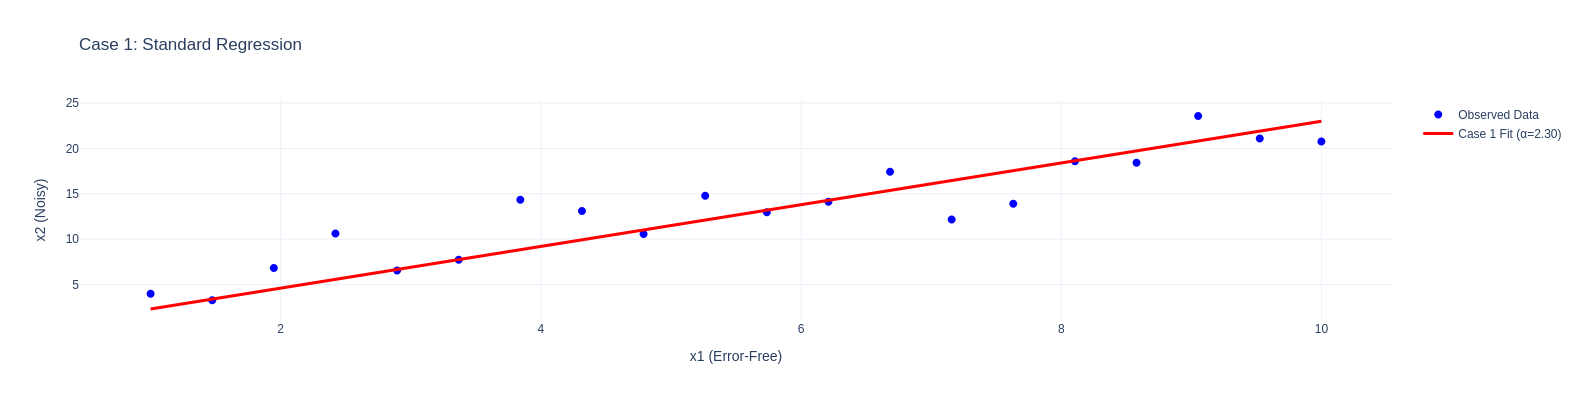

In [2]:
import numpy as np
import plotly.graph_objects as go
import scipy.optimize as optimize

# Generate Synthetic Data (Error only in x2)
np.random.seed(42)
n_samples = 20
x1_obs = np.linspace(1, 10, n_samples)
true_alpha = 2.5
x2_obs = true_alpha * x1_obs + np.random.normal(0, 3.0, n_samples)


# 1. NLL for Case 1
def nll_case1(alpha_guess):
    x2_pred = alpha_guess[0] * x1_obs
    e = x2_obs - x2_pred
    return np.sum(e**2)


# 2. Minimize to find alpha_hat
result_case1 = optimize.minimize(nll_case1, x0=[1.0], method="Nelder-Mead")
alpha_hat = result_case1.x[0]

# 3. Construct M_hat and U_hat matrices
x2_pred = alpha_hat * x1_obs
e_hat = x2_obs - x2_pred

M_hat = np.column_stack((x1_obs, x2_pred))
U_hat = np.column_stack((np.zeros_like(x1_obs), e_hat))

print("--- Task 1 Solution (Case 1) ---")
print(f"True Alpha:      {true_alpha}")
print(f"Estimated Alpha: {alpha_hat:.4f}")
print(f"\nFirst 3 rows of M_hat:\n{M_hat[:3]}")
print(f"\nFirst 3 rows of U_hat:\n{U_hat[:3]}")

# Plotting the Fit
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=x1_obs,
        y=x2_obs,
        mode="markers",
        name="Observed Data",
        marker=dict(color="blue", size=8),
    )
)
fig.add_trace(
    go.Scatter(
        x=x1_obs,
        y=x2_pred,
        mode="lines",
        name=f"Case 1 Fit (α={alpha_hat:.2f})",
        line=dict(color="red", width=3),
    )
)
fig.update_layout(
    title="Case 1: Standard Regression",
    xaxis_title="x1 (Error-Free)",
    yaxis_title="x2 (Noisy)",
    template="plotly_white",
    height=400,
)
fig.show()

---
## Task 2: The Error-in-Variables Model (Case 2)

In Case 2, **both variables contain measurement errors**. If we apply the standard Case 1 regression to this data, it will underestimate the slope (a phenomenon known as *attenuation bias*).

To find the true relationship, we formulate an MLE problem that simultaneously optimizes the global slope ($\alpha$) **and** the estimated true values ($\hat{x}_1^i$) for every single data point. 

For a dataset of $N=20$, our optimizer must find **21 parameters** (1 slope + 20 true $x_1$ coordinates). 

The decomposition of $X = \hat{M} + \hat{U}$ now accounts for errors in both dimensions:
$$\hat{M} = \begin{pmatrix} \hat{x}_1^1 & \hat{\alpha}\hat{x}_1^1 \\ \vdots & \vdots \\ \hat{x}_1^n & \hat{\alpha}\hat{x}_1^n \end{pmatrix}, \quad \hat{U} = \begin{pmatrix} \hat{e}_1^1 & \hat{e}_2^1 \\ \vdots & \vdots \\ \hat{e}_1^n & \hat{e}_2^n \end{pmatrix}$$

**Your Goal:**
1. We will generate a new dataset with noise in *both* variables.
2. Complete the simultaneous NLL function for Case 2.
3. Optimize the parameters to recover a more accurate slope!

--- Task 2 Solution (Case 2) ---
True Alpha:      2.5
Est. TLS Alpha:  2.3986


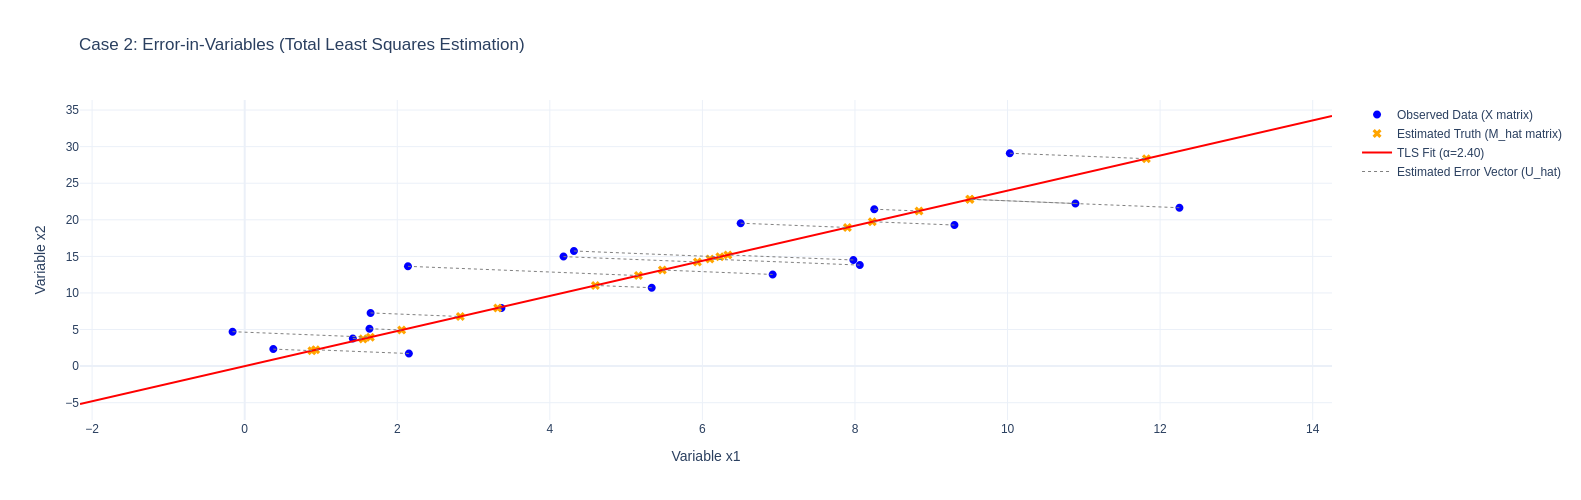

In [7]:
import numpy as np
import plotly.graph_objects as go
import scipy.optimize as optimize

# Generate Case 2 Data: Errors in BOTH variables
np.random.seed(15)
n_samples = 20
x1_true = np.linspace(1, 10, n_samples)
true_alpha = 2.5
x2_true = true_alpha * x1_true

# Observe noisy data
x1_obs = x1_true + np.random.normal(0, 2.0, n_samples)
x2_obs = x2_true + np.random.normal(0, 2.0, n_samples)


# 1. NLL for Case 2
def nll_case2(params):
    alpha_guess = params[0]
    x1_hat = params[1:]  # 20 true x1 values

    # Calculate errors based on the estimated truth
    e1 = x1_obs - x1_hat
    e2 = x2_obs - (alpha_guess * x1_hat)

    return np.sum(e1**2) + np.sum(e2**2)


# 2. Minimize
initial_guess = [1.0] + list(x1_obs)
result_case2 = optimize.minimize(nll_case2, x0=initial_guess, method="L-BFGS-B")

alpha_hat_case2 = result_case2.x[0]
x1_hat_final = result_case2.x[1:]
x2_hat_final = alpha_hat_case2 * x1_hat_final

# 3. Reconstruct Matrices
M_hat = np.column_stack((x1_hat_final, x2_hat_final))
U_hat = np.column_stack((x1_obs - x1_hat_final, x2_obs - x2_hat_final))

print("--- Task 2 Solution (Case 2) ---")
print(f"True Alpha:      {true_alpha}")
print(f"Est. TLS Alpha:  {alpha_hat_case2:.4f}")

# 4. Visualization
fig = go.Figure()

# Plot Observed Data
fig.add_trace(
    go.Scatter(
        x=x1_obs,
        y=x2_obs,
        mode="markers",
        name="Observed Data (X matrix)",
        marker=dict(color="blue", size=8),
    )
)

# Plot Estimated True Data (on the line)
fig.add_trace(
    go.Scatter(
        x=x1_hat_final,
        y=x2_hat_final,
        mode="markers",
        name="Estimated Truth (M_hat matrix)",
        marker=dict(color="orange", size=8, symbol="x"),
    )
)

# Plot the Fitted Line
x_line = np.array([min(x1_obs) - 2, max(x1_obs) + 2])
fig.add_trace(
    go.Scatter(
        x=x_line,
        y=alpha_hat_case2 * x_line,
        mode="lines",
        name=f"TLS Fit (α={alpha_hat_case2:.2f})",
        line=dict(color="red", width=2),
    )
)

# Draw the error vectors (U_hat)
for i in range(len(x1_obs)):
    fig.add_trace(
        go.Scatter(
            x=[x1_obs[i], x1_hat_final[i]],
            y=[x2_obs[i], x2_hat_final[i]],
            mode="lines",
            line=dict(color="gray", dash="dot", width=1),
            showlegend=(i == 0),
            name="Estimated Error Vector (U_hat)",
        )
    )

fig.update_layout(
    title="Case 2: Error-in-Variables (Total Least Squares Estimation)",
    xaxis_title="Variable x1",
    yaxis_title="Variable x2",
    template="plotly_white",
    height=500,
)
# Force aspect ratio so orthogonal lines actually look perfectly orthogonal on the screen
# fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.show()

---
## 💡 Optional Visual Aid: Vertical vs. Orthogonal Uncertainty

What exactly did we just program? 

When we minimized the NLL in **Case 1**, the optimizer assumed $x_1$ was fixed. Graphically, this means it measures the error strictly vertically. 

When we simultaneously optimized the slope and the $x_1$ coordinates in **Case 2** (maximizing likelihood across $f_1$ and $f_2$), the optimizer was allowed to shift the "true" coordinates horizontally as well. Graphically, this creates *orthogonal* (perpendicular) projections from the data points to the fit line. This is mathematically equivalent to **Total Least Squares**.

**Instructions:**
1. Observe the noisy dataset below. 
2. Toggle between **Case 1 (Vertical Errors)** and **Case 2 (Orthogonal Errors)** to see how the mathematical formulation changes the geometry of the error matrix $U$.
3. Adjust the Slope slider to see how the Sum of Squared Errors (SSE) responds differently under the two regimes.

In [8]:
import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

# Generate visual dataset
np.random.seed(99)
x1_vis = np.linspace(1, 10, 12)
x2_vis = 2.0 * x1_vis + np.random.normal(0, 3.5, 12)

# Sliders
slope_slider = widgets.FloatSlider(value=1.5, min=0.5, max=4.0, step=0.1, description='Assumed Slope α:')
mode_toggle = widgets.ToggleButtons(options=['Case 1 (Vertical)', 'Case 2 (Orthogonal)'], description='Error Model:')

fig = go.FigureWidget()

# Trace 0: The Model line (M_hat)
fig.add_trace(go.Scatter(x=np.array([0, 12]), y=np.array([0, 12])*1.5, mode='lines', line=dict(color='green', width=3), name='M_hat (Model)'))

# Trace 1: The Observed Data (X)
fig.add_trace(go.Scatter(x=x1_vis, y=x2_vis, mode='markers', marker=dict(color='blue', size=10), name='X (Observed)'))

# Setup error lines
for i in range(len(x1_vis)):
    fig.add_trace(go.Scatter(x=[], y=[], mode='lines', line=dict(color='red', width=1.5, dash='dot'), showlegend=(i==0), name='U_hat (Error)'))

fig.update_layout(
    title="Data Decomposition: Model vs Uncertainty", 
    xaxis_title="Variable x1", yaxis_title="Variable x2",
    xaxis=dict(range=[0, 12]), yaxis=dict(range=[0, 25]),
    template="plotly_white", height=500
)

def update_plot(change):
    alpha = slope_slider.value
    mode = mode_toggle.value
    
    # Update Model Line
    fig.data[0].y = np.array([0, 12]) * alpha
    
    total_sse = 0
    
    with fig.batch_update():
        for i in range(len(x1_vis)):
            x_obs, y_obs = x1_vis[i], x2_vis[i]
            
            if "Case 1" in mode:
                # Vertical error
                x_proj, y_proj = x_obs, alpha * x_obs
            else:
                # Orthogonal error (Case 2 Total Least Squares)
                # Projection of point onto line y = alpha * x
                x_proj = (x_obs + alpha * y_obs) / (1 + alpha**2)
                y_proj = alpha * x_proj
            
            # Update Error Lines (U_hat)
            fig.data[2+i].x = [x_obs, x_proj]
            fig.data[2+i].y = [y_obs, y_proj]
            
            # Sum squared distance
            total_sse += (x_obs - x_proj)**2 + (y_obs - y_proj)**2
            
        fig.layout.title.text = f"Data Decomposition | Error Metric (SSE): {total_sse:.2f}"

slope_slider.observe(update_plot, names='value')
mode_toggle.observe(update_plot, names='value')

update_plot(None)
display(widgets.VBox([mode_toggle, slope_slider]), fig)

FigureWidget({
    'data': [{'line': {'color': 'green', 'width': 3},
              'mode': 'lines',
              'name': 'M_hat (Model)',
              'type': 'scatter',
              'uid': '9e07929e-ac89-464a-b6ba-3e298e54ad70',
              'x': {'bdata': 'AAw=', 'dtype': 'i1'},
              'y': {'bdata': 'AAAAAAAAAAAAAAAAAAAyQA==', 'dtype': 'f8'}},
             {'marker': {'color': 'blue', 'size': 10},
              'mode': 'markers',
              'name': 'X (Observed)',
              'type': 'scatter',
              'uid': '4648126a-7bba-424e-9fc7-5777b751b557',
              'x': {'bdata': ('AAAAAAAA8D8YXXTRRRf9PxhddNFFFw' ... 'iiiy66IEBddNFFF10iQAAAAAAAACRA'),
                    'dtype': 'f8'},
              'y': {'bdata': ('hLoAxSQH+D8U0oUKXKwlQOPjPch7Dh' ... 'TQ2zLhIEBu8V4kascxQAI+HdgdZjZA'),
                    'dtype': 'f8'}},
             {'line': {'color': 'red', 'dash': 'dot', 'width': 1.5},
              'mode': 'lines',
              'name': 'U_hat (Error)',
    